
=== ADVANCED SQL ANALYSIS OUTPUT ===
primary_language  total_developers  avg_salary_usd  avg_experience_years  salary_rank  diff_from_market_avg
            Rust               191       127228.42                   6.1            1              19022.61
              Go               319       120359.17                   6.2            2              12153.36
      TypeScript               441       112418.63                   5.8            3               4212.82
             SQL               259       105393.46                   5.6            4              -2812.35
          Python               566       105283.84                   6.3            5              -2921.98
            Java               136       100210.77                   5.9            6              -7995.04
      JavaScript               479        99571.23                   6.1            7              -8634.58
             C++               109        95180.97                   6.2            8             

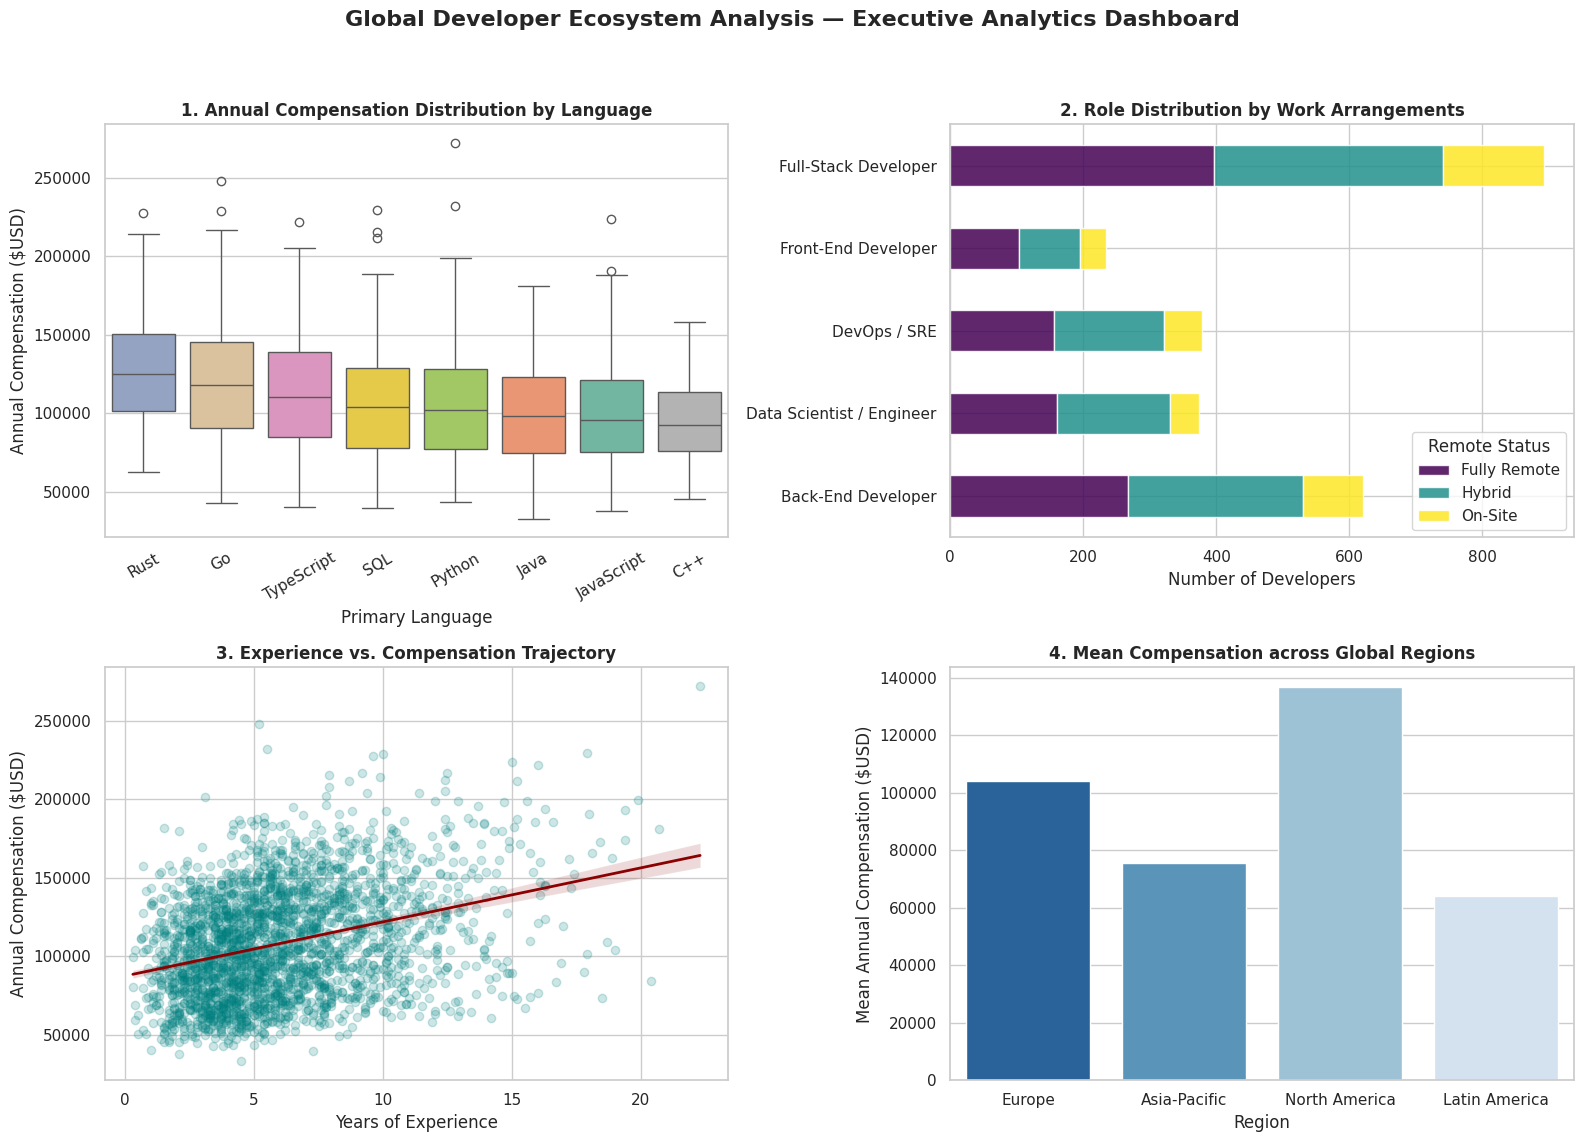

In [3]:
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# Set random seed for reproducibility
np.random.seed(42)

# 1. DATA GENERATION & SYNTHETIC ETL PIPELINE
n_samples = 2500

languages = [
    'Python',
    'JavaScript',
    'TypeScript',
    'Go',
    'Rust',
    'SQL',
    'Java',
    'C++',
]
roles = [
    'Full-Stack Developer',
    'Back-End Developer',
    'Data Scientist / Engineer',
    'DevOps / SRE',
    'Front-End Developer',
]
experience_levels = [
    'Entry-level (<2 yrs)',
    'Mid-level (2-5 yrs)',
    'Senior (5-10 yrs)',
    'Lead / Executive (10+ yrs)',
]
regions = [
    'North America',
    'Europe',
    'Asia-Pacific',
    'Latin America',
]

data = {
    'developer_id': [f'DEV_{i:05d}' for i in range(1, n_samples + 1)],
    'primary_language': np.random.choice(
        languages, size=n_samples, p=[0.22, 0.20, 0.18, 0.12, 0.08, 0.10, 0.06, 0.04]
    ),
    'primary_role': np.random.choice(
        roles, size=n_samples, p=[0.35, 0.25, 0.15, 0.15, 0.10]
    ),
    'experience_level': np.random.choice(
        experience_levels, size=n_samples, p=[0.20, 0.40, 0.30, 0.10]
    ),
    'region': np.random.choice(regions, size=n_samples, p=[0.40, 0.30, 0.20, 0.10]),
    'years_experience': np.random.gamma(shape=3.0, scale=2.0, size=n_samples).round(1),
    'remote_status': np.random.choice(
        ['Fully Remote', 'Hybrid', 'On-Site'], size=n_samples, p=[0.45, 0.40, 0.15]
    ),
}

df = pd.DataFrame(data)

# Salary Generation Logic with Realistic Variances
base_salaries = {
    'Rust': 95000,
    'Go': 90000,
    'TypeScript': 82000,
    'Python': 80000,
    'SQL': 78000,
    'JavaScript': 75000,
    'Java': 74000,
    'C++': 72000,
}
region_multipliers = {
    'North America': 1.35,
    'Europe': 1.0,
    'Asia-Pacific': 0.75,
    'Latin America': 0.65,
}

df['base_comp'] = df['primary_language'].map(base_salaries)
df['region_mult'] = df['region'].map(region_multipliers)

# Final Compensation Formula with Log-Normal Noise
noise = np.random.normal(0, 0.15, n_samples)
df['annual_compensation_usd'] = (
    (df['base_comp'] * df['region_mult'] * (1 + (df['years_experience'] * 0.04)))
    * np.exp(noise)
).round(2)

# Introduce realistic Data Quality Issues (Nulls & Outliers) to test cleaning
df.loc[df.sample(frac=0.03).index, 'annual_compensation_usd'] = np.nan
df.loc[df.sample(frac=0.01).index, 'years_experience'] = -999.0  # Invalid entry marker

# 2. DATA CLEANING & WRANGLING
# Clean invalid experience numbers
df['years_experience'] = df['years_experience'].apply(
    lambda x: np.nan if x < 0 else x
)
df['years_experience'] = df['years_experience'].fillna(
    df['years_experience'].median()
)

# Impute Compensation based on Role & Language medians
df['annual_compensation_usd'] = df['annual_compensation_usd'].fillna(
    df.groupby(['primary_language', 'region'])['annual_compensation_usd'].transform(
        'median'
    )
)

# Drop remaining helper columns
df.drop(columns=['base_comp', 'region_mult'], inplace=True)


# 3. ADVANCED SQL ANALYSIS (IN-MEMORY SQLITE)
conn = sqlite3.connect(':memory:')
df.to_sql('developers', conn, index=False, if_exists='replace')

sql_query = """
WITH LanguageStats AS (
    SELECT
        primary_language,
        COUNT(developer_id) AS total_developers,
        AVG(annual_compensation_usd) AS avg_salary,
        AVG(years_experience) AS avg_exp
    FROM developers
    GROUP BY primary_language
),
RankedStats AS (
    SELECT
        primary_language,
        total_developers,
        ROUND(avg_salary, 2) AS avg_salary_usd,
        ROUND(avg_exp, 1) AS avg_experience_years,
        RANK() OVER (ORDER BY avg_salary DESC) AS salary_rank,
        ROUND(avg_salary - AVG(avg_salary) OVER(), 2) AS diff_from_market_avg
    FROM LanguageStats
)
SELECT *
FROM RankedStats
ORDER BY salary_rank ASC;
"""

df_sql_insights = pd.read_sql_query(sql_query, conn)
print('\n=== ADVANCED SQL ANALYSIS OUTPUT ===')
print(df_sql_insights.to_string(index=False))


# 4. STATISTICAL HYPOTHESIS TESTING
# Hypothesis: Remote developers earn significantly different compensation than On-Site developers in NA.
na_remote = df[(df['region'] == 'North America') & (df['remote_status'] == 'Fully Remote')]['annual_compensation_usd']
na_onsite = df[(df['region'] == 'North America') & (df['remote_status'] == 'On-Site')]['annual_compensation_usd']

t_stat, p_val = stats.ttest_ind(na_remote, na_onsite, equal_var=False)

print('\n=== STATISTICAL HYPOTHESIS TEST RESULTS ===')
print(f'Two-sample Welch\'s t-test (NA Remote vs On-Site Compensation):')
print(f't-statistic: {t_stat:.4f}, p-value: {p_val:.4f}')
if p_val < 0.05:
    print('Result: Statistically significant difference in compensation tiers (p < 0.05).')
else:
    print('Result: Fail to reject null hypothesis; no significant difference detected.')


# 5. DATA VISUALIZATION DASHBOARD (UPDATED)
sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Salary Distribution by Primary Language (Fixed palette warning)
sns.boxplot(
    ax=axes[0, 0],
    data=df,
    x='primary_language',
    y='annual_compensation_usd',
    hue='primary_language',
    palette='Set2',
    order=df_sql_insights['primary_language'],
    legend=False,
)
axes[0, 0].set_title(
    '1. Annual Compensation Distribution by Language',
    fontsize=12,
    fontweight='bold',
)
axes[0, 0].set_xlabel('Primary Language')
axes[0, 0].set_ylabel('Annual Compensation ($USD)')
axes[0, 0].tick_params(axis='x', rotation=30)

# Chart 2: Developer Count by Role & Remote Status
role_remote_counts = (
    df.groupby(['primary_role', 'remote_status']).size().unstack(fill_value=0)
)
role_remote_counts.plot(
    kind='barh', stacked=True, ax=axes[0, 1], colormap='viridis', alpha=0.85
)
axes[0, 1].set_title(
    '2. Role Distribution by Work Arrangements', fontsize=12, fontweight='bold'
)
axes[0, 1].set_xlabel('Number of Developers')
axes[0, 1].set_ylabel('')
axes[0, 1].legend(title='Remote Status')

# Chart 3: Experience vs Compensation
sns.regplot(
    ax=axes[1, 0],
    data=df,
    x='years_experience',
    y='annual_compensation_usd',
    scatter_kws={'alpha': 0.2, 'color': 'teal'},
    line_kws={'color': 'darkred', 'linewidth': 2},
)
axes[1, 0].set_title(
    '3. Experience vs. Compensation Trajectory', fontsize=12, fontweight='bold'
)
axes[1, 0].set_xlabel('Years of Experience')
axes[1, 0].set_ylabel('Annual Compensation ($USD)')

# Chart 4: Average Salary Variance by Region (Fixed ci and palette warnings)
sns.barplot(
    ax=axes[1, 1],
    data=df,
    x='region',
    y='annual_compensation_usd',
    estimator=np.mean,
    errorbar=None,
    hue='region',
    palette='Blues_r',
    legend=False,
)
axes[1, 1].set_title(
    '4. Mean Compensation across Global Regions', fontsize=12, fontweight='bold'
)
axes[1, 1].set_xlabel('Region')
axes[1, 1].set_ylabel('Mean Annual Compensation ($USD)')

plt.suptitle(
    'Global Developer Ecosystem Analysis — Executive Analytics Dashboard',
    fontsize=16,
    fontweight='bold',
    y=0.98,
)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('executive_capstone_dashboard.png', dpi=300)
plt.show()